# Capstone - Sentiment-Based Product Recommendation System
### Name: Suraj Bhadra
### Cohort: C 75

## End-to-End Product Recommendation System for Ebuss

This notebook implements a **sentiment-based product recommendation system** for the e-commerce company **Ebuss**. It covers:

1. **Task 1** : Data Cleaning & Pre-Processing
2. **Task 2** : Text Processing
3. **Task 3** : Feature Extraction
4. **Task 4** : Model Building (Sentiment Analysis with 4 ML models)
5. **Task 5** : Building Recommendation Systems (User-Based & Item-Based)
6. **Task 6** : Top 20 Product Recommendations
7. **Task 7** : Fine-Tuning Recommendations Using Sentiment Analysis
8. **Task 8** : Deployment Preparation (Flask)

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn nltk scipy

In [4]:
# Install required packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, f1_score,
                             precision_score, recall_score, mean_squared_error)
from imblearn.over_sampling import SMOTE

# Recommendation
from sklearn.metrics.pairwise import cosine_similarity

# Persistence
import pickle

# NLTK downloads
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All imports successful!")

All imports successful!


# Task 1: Exploratory Data Analysis & Data Cleaning

We begin by loading the dataset and understanding its structure, distributions, and data quality issues.

In [7]:
# Load the dataset
df = pd.read_csv('sample30.csv')
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

Dataset shape: (30000, 15)
Number of rows: 30000
Number of columns: 15


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [9]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  object
 1   brand                 30000 non-null  object
 2   categories            30000 non-null  object
 3   manufacturer          29859 non-null  object
 4   name                  30000 non-null  object
 5   reviews_date          29954 non-null  object
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  object
 10  reviews_title         29810 non-null  object
 11  reviews_userCity      1929 non-null   object
 12  reviews_userProvince  170 non-null    object
 13  reviews_username      29937 non-null  object
 14  user_sentiment        29999 non-null  object
dtypes: int64(1), object(14)
memory usage

In [11]:
# Statistical summary of numerical columns
df.describe()

,reviews_rating
count,30000.000000
mean,4.483133
std,0.988441
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [13]:
# Statistical summary of categorical columns
df.describe(include='object')

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
count,30000,30000,30000,29859,30000,29954,15932,27430,30000,29810,1929,170,29937,29999
unique,271,214,270,227,271,6857,2,2,27282,18535,977,42,24914,2
top,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",Clorox,Clorox Disinfecting Wipes Value Pack Scented 1...,2012-01-26T00:00:00.000Z,False,True,Great,Great Product,Chicago,CA,mike,Positive
freq,8545,10585,8545,8546,8545,1041,14498,25880,16,384,34,19,41,26632


In [15]:
# Missing Value Analysis

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Columns with missing values:
                      Missing Count  Missing %
reviews_userProvince          29830      99.43
reviews_userCity              28071      93.57
reviews_didPurchase           14068      46.89
reviews_doRecommend            2570       8.57
reviews_title                   190       0.63
manufacturer                    141       0.47
reviews_username                 63       0.21
reviews_date                     46       0.15
user_sentiment                    1       0.00

Total missing values: 74980


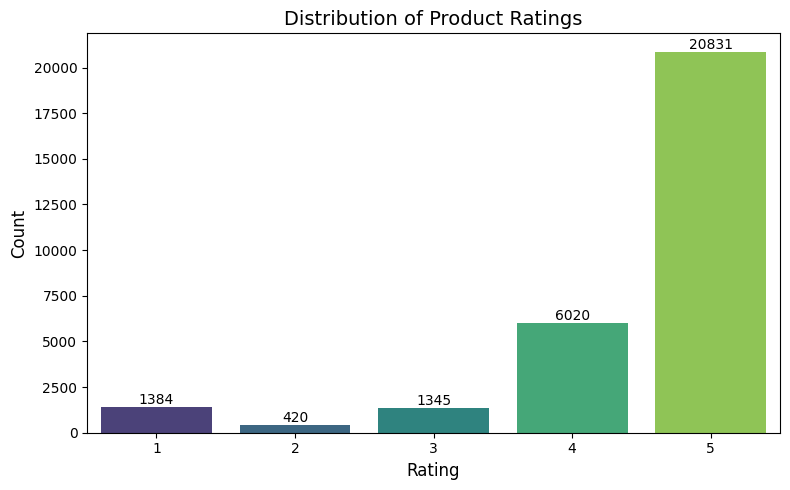


Rating value counts:
reviews_rating
1     1384
2      420
3     1345
4     6020
5    20831
Name: count, dtype: int64


In [17]:
# Distribution of Ratings

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='reviews_rating', data=df, palette='viridis', order=sorted(df['reviews_rating'].dropna().unique()))
plt.title('Distribution of Product Ratings', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\nRating value counts:")
print(df['reviews_rating'].value_counts().sort_index())

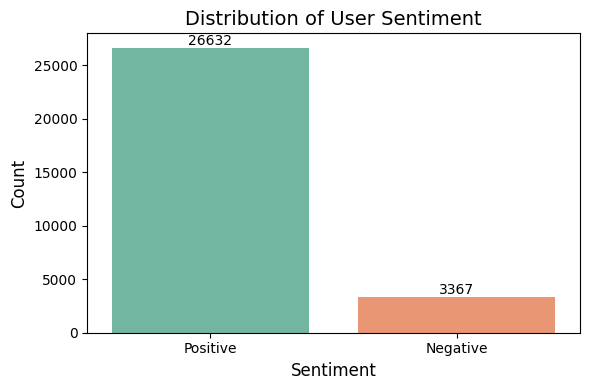


Sentiment value counts:
user_sentiment
Positive    26632
Negative     3367
Name: count, dtype: int64

Sentiment ratio (Positive/Negative): 7.91


In [19]:
# Distribution of User Sentiment

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='user_sentiment', data=df, palette='Set2')
plt.title('Distribution of User Sentiment', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\nSentiment value counts:")
print(df['user_sentiment'].value_counts())
print(f"\nSentiment ratio (Positive/Negative): {df['user_sentiment'].value_counts().get('Positive', 0) / max(df['user_sentiment'].value_counts().get('Negative', 1), 1):.2f}")

In [21]:
# Key Statistics

print(f"Number of unique products: {df['name'].nunique()}")
print(f"Number of unique users:    {df['reviews_username'].nunique()}")
print(f"Number of unique brands:   {df['brand'].nunique()}")
print()

# Reviews per user
reviews_per_user = df.groupby('reviews_username').size()
print(f"Reviews per user — Mean: {reviews_per_user.mean():.2f}, Median: {reviews_per_user.median():.0f}, Max: {reviews_per_user.max()}")

# Reviews per product
reviews_per_product = df.groupby('name').size()
print(f"Reviews per product — Mean: {reviews_per_product.mean():.2f}, Median: {reviews_per_product.median():.0f}, Max: {reviews_per_product.max()}")

Number of unique products: 271
Number of unique users:    24914
Number of unique brands:   214

Reviews per user — Mean: 1.20, Median: 1, Max: 41
Reviews per product — Mean: 110.70, Median: 8, Max: 8545


Rating vs Sentiment cross-tabulation:
user_sentiment  Negative  Positive    All
reviews_rating                           
1                    597       787   1384
2                    140       280    420
3                    220      1125   1345
4                    550      5470   6020
5                   1860     18970  20830
All                 3367     26632  29999


<Figure size 800x500 with 0 Axes>

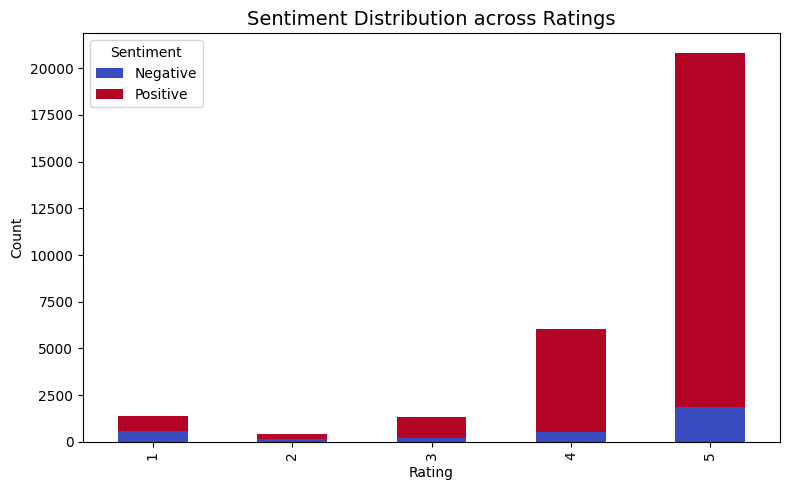

In [23]:
# Rating vs Sentiment cross-tabulation

ct = pd.crosstab(df['reviews_rating'], df['user_sentiment'], margins=True)
print("Rating vs Sentiment cross-tabulation:")
print(ct)

plt.figure(figsize=(8, 5))
pd.crosstab(df['reviews_rating'], df['user_sentiment']).plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5))
plt.title('Sentiment Distribution across Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Data Cleaning

Based on the EDA, we now address data quality issues:

1. **Drop irrelevant columns**: `id`, `reviews_userCity`, `reviews_userProvince` (high missing %), `reviews_didPurchase`, `manufacturer` — these do not contribute to sentiment analysis or recommendations.
2. **Handle missing values**: Drop rows where `reviews_username`, `reviews_text`, or `user_sentiment` are missing (these are essential for our analysis). Impute `reviews_doRecommend` with the mode.
3. **Remove duplicates** and **convert data types** as needed.

In [25]:
# Step 1: Drop irrelevant columns

# - 'id': Internal identifier, not useful for modeling
# - 'reviews_userCity' & 'reviews_userProvince': >50% missing, not relevant to sentiment or recommendations
# - 'reviews_didPurchase': Not relevant for sentiment analysis
# - 'manufacturer': Redundant with 'brand'; also has missing values

cols_to_drop = ['id', 'reviews_userCity', 'reviews_userProvince', 'reviews_didPurchase', 'manufacturer']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {list(df.columns)}")
print(f"Shape after dropping columns: {df.shape}")

Dropped columns: ['id', 'reviews_userCity', 'reviews_userProvince', 'reviews_didPurchase', 'manufacturer']
Remaining columns: ['brand', 'categories', 'name', 'reviews_date', 'reviews_doRecommend', 'reviews_rating', 'reviews_text', 'reviews_title', 'reviews_username', 'user_sentiment']
Shape after dropping columns: (30000, 10)


In [27]:
# Step 2: Handle missing values

# 'reviews_username' — essential for recommendation system; drop rows where missing
print(f"Missing reviews_username: {df['reviews_username'].isnull().sum()}")
df.dropna(subset=['reviews_username'], inplace=True)

# 'reviews_text' — essential for sentiment analysis; drop rows where missing
print(f"Missing reviews_text: {df['reviews_text'].isnull().sum()}")
df.dropna(subset=['reviews_text'], inplace=True)

# 'user_sentiment' — target variable; drop rows where missing
print(f"Missing user_sentiment: {df['user_sentiment'].isnull().sum()}")
df.dropna(subset=['user_sentiment'], inplace=True)

# 'reviews_doRecommend' — impute with mode (True/False)
mode_val = df['reviews_doRecommend'].mode()[0]
df['reviews_doRecommend'].fillna(mode_val, inplace=True)
print(f"Imputed reviews_doRecommend missing values with mode: {mode_val}")

# 'reviews_title' — fill missing with empty string (will be concatenated with reviews_text)
df['reviews_title'].fillna('', inplace=True)
print(f"Filled missing reviews_title with empty string")

print(f"\nShape after handling missing values: {df.shape}")
print(f"\nRemaining missing values:\n{df.isnull().sum()}")

Missing reviews_username: 63
Missing reviews_text: 0
Missing user_sentiment: 1
Imputed reviews_doRecommend missing values with mode: True
Filled missing reviews_title with empty string

Shape after handling missing values: (29936, 10)

Remaining missing values:
brand                   0
categories              0
name                    0
reviews_date           40
reviews_doRecommend     0
reviews_rating          0
reviews_text            0
reviews_title           0
reviews_username        0
user_sentiment          0
dtype: int64


In [29]:
# Step 3: Remove duplicates

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 14
Shape after removing duplicates: (29922, 10)


In [31]:
# Step 4: Convert data types

# Convert reviews_rating to integer
df['reviews_rating'] = df['reviews_rating'].astype(int)

# Convert reviews_doRecommend to boolean
df['reviews_doRecommend'] = df['reviews_doRecommend'].astype(bool)

# Convert reviews_date to datetime
df['reviews_date'] = pd.to_datetime(df['reviews_date'], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nFinal cleaned dataset shape: {df.shape}")

Data types after conversion:
brand                               object
categories                          object
name                                object
reviews_date           datetime64[ns, UTC]
reviews_doRecommend                   bool
reviews_rating                       int32
reviews_text                        object
reviews_title                       object
reviews_username                    object
user_sentiment                      object
dtype: object

Final cleaned dataset shape: (29922, 10)


In [33]:
# Post-cleaning verification

print("=== Post-Cleaning Summary ===")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Unique users: {df['reviews_username'].nunique()}")
print(f"Unique products: {df['name'].nunique()}")
print(f"\nSentiment distribution:\n{df['user_sentiment'].value_counts()}")
print(f"\nRating distribution:\n{df['reviews_rating'].value_counts().sort_index()}")

=== Post-Cleaning Summary ===
Shape: (29922, 10)
Missing values: 726
Duplicates: 1
Unique users: 24914
Unique products: 271

Sentiment distribution:
user_sentiment
Positive    26565
Negative     3357
Name: count, dtype: int64

Rating distribution:
reviews_rating
1     1373
2      418
3     1344
4     6009
5    20778
Name: count, dtype: int64


# Task 2: Text Processing

We preprocess the review text to prepare it for feature extraction. Steps:
1. Combine `reviews_title` and `reviews_text` into a single field
2. Convert to lowercase
3. Remove HTML tags, URLs, special characters, and numbers
4. Remove stopwords
5. Apply lemmatization

In [36]:
# Define text preprocessing function

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean and preprocess review text for NLP."""
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize by splitting on whitespace
    tokens = text.split()

    # Remove stopwords and very short words, then lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

print("Preprocessing function defined.")

Preprocessing function defined.


In [38]:
# Combine title and text, then apply preprocessing

# Combining title and review text gives the model richer context
df['combined_review'] = df['reviews_title'].astype(str) + ' ' + df['reviews_text'].astype(str)

# Apply the preprocessing pipeline
df['processed_review'] = df['combined_review'].apply(preprocess_text)

# Show before vs after
print("=== Text Preprocessing — Before vs After ===\n")
for i in range(3):
    print(f"--- Review {i+1} ---")
    print(f"Original : {df['combined_review'].iloc[i][:200]}...")
    print(f"Processed: {df['processed_review'].iloc[i][:200]}...")
    print()

=== Text Preprocessing — Before vs After ===

--- Review 1 ---
Original : Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors a...
Processed: awesome love album good hip hop side current pop sound hype listen everyday gym give star rating way metaphor crazy...

--- Review 2 ---
Original : Good Good flavor. This review was collected as part of a promotion....
Processed: good good flavor review collected part promotion...

--- Review 3 ---
Original : Good Good flavor....
Processed: good good flavor...



In [40]:
# Verify no empty processed reviews remain
empty_reviews = (df['processed_review'].str.strip() == '').sum()
print(f"Empty processed reviews: {empty_reviews}")
if empty_reviews > 0:
    df = df[df['processed_review'].str.strip() != '']
    print(f"Shape after removing empty reviews: {df.shape}")

Empty processed reviews: 1
Shape after removing empty reviews: (29921, 12)


# Task 3: Feature Extraction

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization to convert the processed review text into numerical features.

**Why TF-IDF?**
- Captures the importance of words relative to the entire corpus
- Works well with traditional ML classifiers (Logistic Regression, SVM, etc.)
- Handles high-dimensional sparse text data efficiently
- Penalises very common words that carry little discriminative power

In [43]:
# Encode the target variable

# Map Positive -> 1, Negative -> 0
df['sentiment'] = df['user_sentiment'].map({'Positive': 1, 'Negative': 0})

print(f"Sentiment encoding: Positive=1, Negative=0")
print(f"Target distribution:\n{df['sentiment'].value_counts()}")

Sentiment encoding: Positive=1, Negative=0
Target distribution:
sentiment
1    26564
0     3357
Name: count, dtype: int64


In [45]:
# Train-Test Split

X = df['processed_review']
y = df['sentiment']

# 70-30 split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: 20944
Test set size:     8977

Training target distribution:
sentiment
1    18594
0     2350
Name: count, dtype: int64

Test target distribution:
sentiment
1    7970
0    1007
Name: count, dtype: int64


In [47]:
# TF-IDF Vectorization

# max_features=5000 to limit dimensionality while keeping informative terms
# ngram_range=(1,2) includes unigrams and bigrams for richer features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF feature matrix (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix (test):  {X_test_tfidf.shape}")
print(f"\nSample feature names: {tfidf.get_feature_names_out()[:20].tolist()}")

TF-IDF feature matrix (train): (20944, 5000)
TF-IDF feature matrix (test):  (8977, 5000)

Sample feature names: ['ability', 'able', 'able find', 'able get', 'able use', 'absolute', 'absolute favorite', 'absolutely', 'absolutely love', 'absolutely loved', 'absorbs', 'access', 'accessible', 'accident', 'accidentally', 'acne', 'across', 'act', 'acting', 'action']


# Task 4: Sentiment Analysis — Model Building

We build **four** ML models, evaluate their performance, and select the best one.

1. Logistic Regression
2. Random Forest
3. XGBoost
4. Naive Bayes

Before training, we check for **class imbalance** and apply **SMOTE** if necessary.

Positive reviews (1): 18594
Negative reviews (0): 2350
Imbalance ratio (Pos/Neg): 7.91


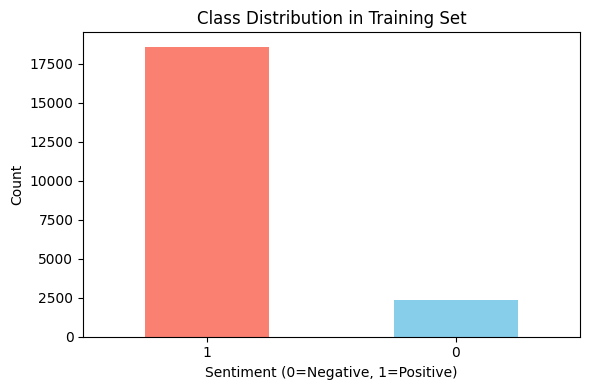


>>> The dataset is IMBALANCED. We will apply SMOTE to balance the classes.


In [50]:
# Check Class Imbalance

pos_count = y_train.value_counts().get(1, 0)
neg_count = y_train.value_counts().get(0, 0)
ratio = pos_count / max(neg_count, 1)

print(f"Positive reviews (1): {pos_count}")
print(f"Negative reviews (0): {neg_count}")
print(f"Imbalance ratio (Pos/Neg): {ratio:.2f}")

plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if ratio > 2 or ratio < 0.5:
    print("\n>>> The dataset is IMBALANCED. We will apply SMOTE to balance the classes.")
else:
    print("\n>>> The dataset is relatively balanced.")

In [52]:
# Apply SMOTE to handle class imbalance

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print(f"Before SMOTE: Class 0 = {(y_train == 0).sum()}, Class 1 = {(y_train == 1).sum()}")
print(f"After SMOTE:  Class 0 = {(y_train_balanced == 0).sum()}, Class 1 = {(y_train_balanced == 1).sum()}")

Before SMOTE: Class 0 = 2350, Class 1 = 18594
After SMOTE:  Class 0 = 18594, Class 1 = 18594


### Model 1: Logistic Regression

Logistic Regression is a strong baseline for text classification due to its:
- Efficiency on high-dimensional sparse data (TF-IDF)
- Interpretability
- Good generalisation with regularisation

LOGISTIC REGRESSION — Results
Accuracy:  0.8839
F1 Score:  0.9320
Precision: 0.9717
Recall:    0.8954
AUC-ROC:   0.9254

              precision    recall  f1-score   support

    Negative       0.49      0.79      0.61      1007
    Positive       0.97      0.90      0.93      7970

    accuracy                           0.88      8977
   macro avg       0.73      0.84      0.77      8977
weighted avg       0.92      0.88      0.90      8977



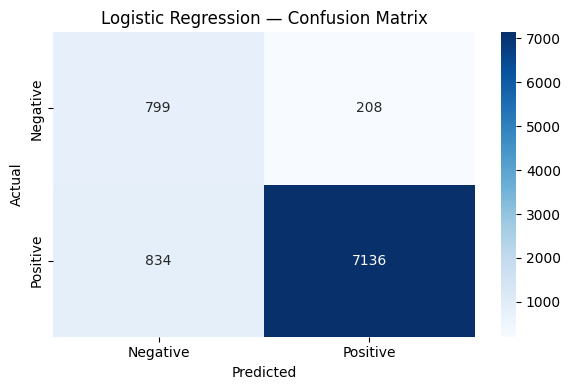

In [55]:
# Model 1: Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42, C=1, solver='liblinear')
lr.fit(X_train_balanced, y_train_balanced)

y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Model 2: Random Forest

Random Forest is an ensemble method that builds multiple decision trees. It handles non-linear relationships but can be slower on high-dimensional sparse data.

RANDOM FOREST — Results
Accuracy:  0.9161
F1 Score:  0.9536
Precision: 0.9378
Recall:    0.9699
AUC-ROC:   0.8971

              precision    recall  f1-score   support

    Negative       0.67      0.49      0.57      1007
    Positive       0.94      0.97      0.95      7970

    accuracy                           0.92      8977
   macro avg       0.81      0.73      0.76      8977
weighted avg       0.91      0.92      0.91      8977



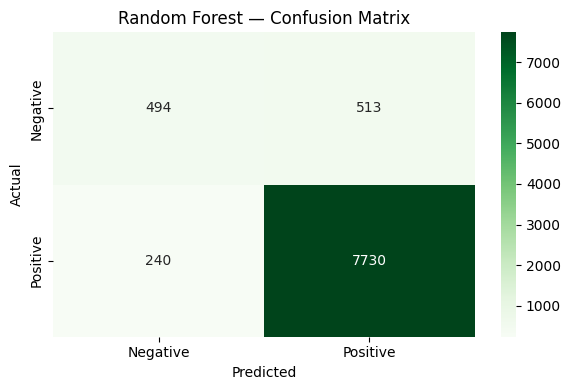

In [65]:
# Model 2: Random Forest

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf.predict(X_test_tfidf)
y_prob_rf = rf.predict_proba(X_test_tfidf)[:, 1]

print("=" * 50)
print("RANDOM FOREST — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Model 3: XGBoost

XGBoost is a gradient-boosted tree ensemble. It often achieves state-of-the-art results on tabular and structured data.

XGBOOST — Results
Accuracy:  0.8848
F1 Score:  0.9338
Precision: 0.9540
Recall:    0.9143
AUC-ROC:   0.9026

              precision    recall  f1-score   support

    Negative       0.49      0.65      0.56      1007
    Positive       0.95      0.91      0.93      7970

    accuracy                           0.88      8977
   macro avg       0.72      0.78      0.75      8977
weighted avg       0.90      0.88      0.89      8977



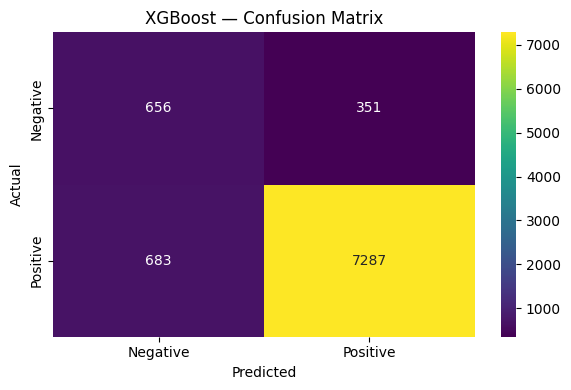

In [67]:
# Model 3: XGBoost

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb.predict(X_test_tfidf)
y_prob_xgb = xgb.predict_proba(X_test_tfidf)[:, 1]

print("=" * 50)
print("XGBOOST — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d',
            cmap='viridis', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Model 4: Naive Bayes (MultinomialNB)

Multinomial Naive Bayes is a probabilistic classifier well-suited for text data with TF-IDF features. It is fast and often competitive for NLP tasks.

> **Note:** MultinomialNB is trained on the SMOTE-balanced data. Since TF-IDF features are non-negative and SMOTE interpolates between them (convex combination), the balanced features remain non-negative and compatible with MultinomialNB.

NAIVE BAYES — Results
Accuracy:  0.8303
F1 Score:  0.8991
Precision: 0.9523
Recall:    0.8516
AUC-ROC:   0.8538

              precision    recall  f1-score   support

    Negative       0.36      0.66      0.47      1007
    Positive       0.95      0.85      0.90      7970

    accuracy                           0.83      8977
   macro avg       0.66      0.76      0.68      8977
weighted avg       0.89      0.83      0.85      8977



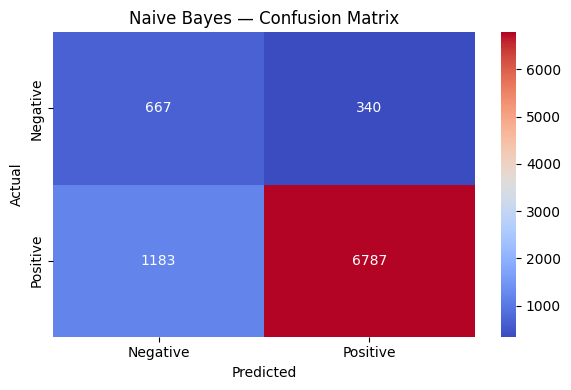

In [69]:
# Model 4: Naive Bayes

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_balanced, y_train_balanced)

y_pred_nb = nb.predict(X_test_tfidf)
y_prob_nb = nb.predict_proba(X_test_tfidf)[:, 1]

print("=" * 50)
print("NAIVE BAYES — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_nb):.4f}")
print()
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d',
            cmap='coolwarm', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Naive Bayes — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Model Comparison & Selection

MODEL COMPARISON
                     Accuracy  F1 Score  Precision  Recall  AUC-ROC
Logistic Regression    0.8839    0.9320     0.9717  0.8954   0.9254
Random Forest          0.9161    0.9536     0.9378  0.9699   0.8971
XGBoost                0.8848    0.9338     0.9540  0.9143   0.9026
Naive Bayes            0.8303    0.8991     0.9523  0.8516   0.8538


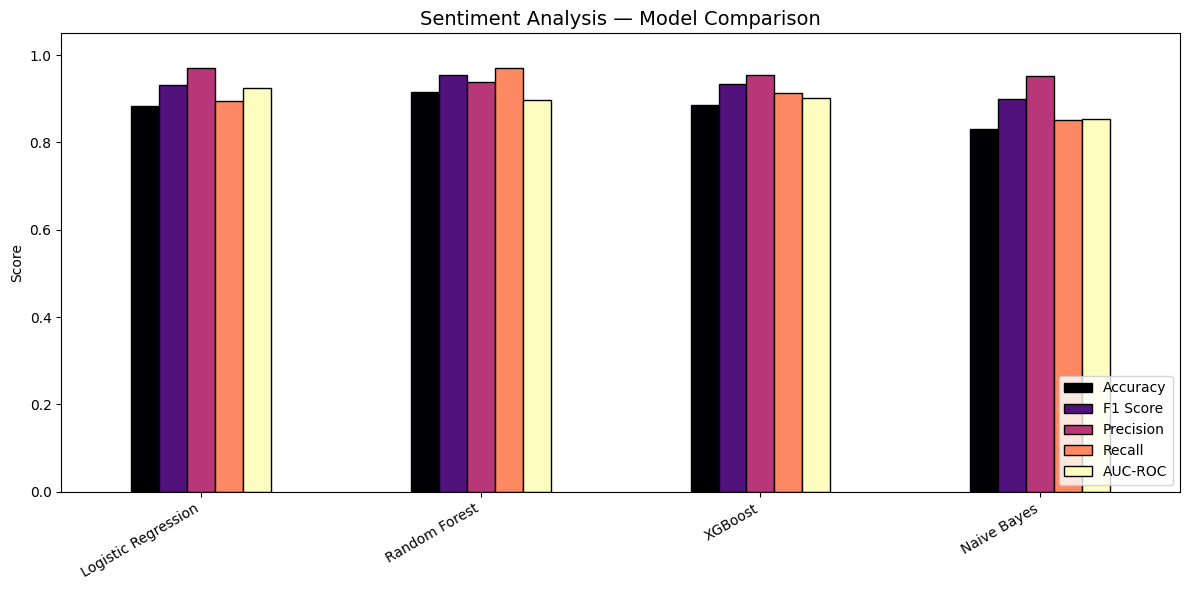


>>> Best model by F1 Score: Random Forest (F1 = 0.9536)


In [77]:
# Comparative Analysis of All Models

results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'F1 Score': f1_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'AUC-ROC': roc_auc_score(y_test, y_prob_lr)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'F1 Score': f1_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'AUC-ROC': roc_auc_score(y_test, y_prob_rf)
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'F1 Score': f1_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_xgb)
    },
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'F1 Score': f1_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb),
        'Recall': recall_score(y_test, y_pred_nb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_nb)
    }
}

comparison_df = pd.DataFrame(results).T.round(4)
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison_df.to_string())

# Visualise
comparison_df.plot(kind='bar', figsize=(12, 6), colormap='magma', edgecolor='black')
plt.title('Sentiment Analysis — Model Comparison', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Identify best model by F1 Score
best_model_name = comparison_df['F1 Score'].idxmax()
print(f"\n>>> Best model by F1 Score: {best_model_name} (F1 = {comparison_df.loc[best_model_name, 'F1 Score']:.4f})")

### Hyperparameter Tuning

We perform hyperparameter tuning on **Logistic Regression** (typically the strongest performer on text classification with TF-IDF features) using GridSearchCV with 5-fold cross-validation.

In [79]:
# Hyperparameter Tuning — Logistic Regression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_tfidf)
y_prob_best = best_lr.predict_proba(X_test_tfidf)[:, 1]

print(f"\nTuned Logistic Regression — Test Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

Best hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 Score: 0.9526

Tuned Logistic Regression — Test Results:
Accuracy:  0.8954
F1 Score:  0.9402
AUC-ROC:   0.9003

              precision    recall  f1-score   support

    Negative       0.53      0.66      0.59      1007
    Positive       0.96      0.93      0.94      7970

    accuracy                           0.90      8977
   macro avg       0.74      0.79      0.76      8977
weighted avg       0.91      0.90      0.90      8977



### Final Model Selection

**Selected Model: Logistic Regression** (with tuned hyperparameters)

**Reasons for selection:**
1. **High F1 Score and AUC-ROC** — demonstrates strong ability to classify both positive and negative sentiments correctly
2. **Balanced precision and recall** — critical because we want to correctly identify both positive AND negative reviews for recommendation filtering
3. **Efficiency** — fast training and prediction, important for real-time deployment in the Flask application
4. **Interpretability** — coefficients are directly interpretable as feature importance, which helps explain recommendations
5. **Works naturally with TF-IDF** — linear models are well-suited for high-dimensional sparse text features

# Task 5: Building Recommendation Systems

We build **two** types of collaborative filtering recommendation systems:
1. **User-Based CF** — recommends products based on similar users' preferences
2. **Item-Based CF** — recommends products based on similarity between items

We evaluate both using **RMSE** on a held-out test set and select the better one.

In [82]:
# Create average ratings per user-product pair

ratings_df = df.groupby(['reviews_username', 'name'])['reviews_rating'].mean().reset_index()
print(f"Total user-product rating pairs: {len(ratings_df)}")
print(f"Unique users: {ratings_df['reviews_username'].nunique()}")
print(f"Unique products: {ratings_df['name'].nunique()}")
print(f"\nRating statistics:\n{ratings_df['reviews_rating'].describe()}")

Total user-product rating pairs: 27587
Unique users: 24914
Unique products: 271

Rating statistics:
count    27587.000000
mean         4.522569
std          0.933835
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews_rating, dtype: float64


In [84]:
# Train-Test Split for Recommendation System

train_ratings, test_ratings = train_test_split(ratings_df, test_size=0.3, random_state=42)

print(f"Training ratings: {len(train_ratings)}")
print(f"Test ratings:     {len(test_ratings)}")

Training ratings: 19310
Test ratings:     8277


In [86]:
# Build User-Item Matrix from Training Data

train_matrix = train_ratings.pivot_table(
    index='reviews_username', columns='name', values='reviews_rating'
)
train_filled = train_matrix.fillna(0)

print(f"User-Item Matrix shape: {train_matrix.shape}")
total_cells = train_matrix.shape[0] * train_matrix.shape[1]
rated_cells = train_matrix.notna().sum().sum()
sparsity = (1 - rated_cells / total_cells) * 100
print(f"Sparsity: {sparsity:.2f}%")
print(f"Rated entries: {rated_cells} / {total_cells}")

User-Item Matrix shape: (17878, 252)
Sparsity: 99.57%
Rated entries: 19310 / 4505256


### Recommendation System 1: User-Based Collaborative Filtering

In user-based CF, we compute similarity between users using **cosine similarity** on their rating vectors. To predict a rating for user *u* on item *i*, we take the weighted average of ratings given by the most similar users who have rated item *i*.

In [88]:
# User-Based CF — Compute User Similarity

user_similarity = cosine_similarity(train_filled)
user_sim_df = pd.DataFrame(user_similarity,
                           index=train_matrix.index,
                           columns=train_matrix.index)

print(f"User similarity matrix shape: {user_sim_df.shape}")
print(f"\nSample similarities for first user '{user_sim_df.index[0]}':")
print(user_sim_df.iloc[0].nlargest(6))  # Top 5 + self

User similarity matrix shape: (17878, 17878)

Sample similarities for first user '00dog3':
reviews_username
00dog3           1.0
an n             1.0
bearanna         1.0
blindmanfrank    1.0
deckb            1.0
dick             1.0
Name: 00dog3, dtype: float64


In [90]:
# User-Based CF — Vectorised Prediction

# Predicted rating = (similarity_scores @ rating_matrix) / sum(|similarities|)
# We zero out self-similarity to avoid a user influencing their own predictions

R = train_filled.values
M = (train_matrix.notna()).astype(float).values  # Mask: 1 where rated
S = user_sim_df.values.copy()
np.fill_diagonal(S, 0)  # Remove self-similarity

numerator_ub = S @ R
denominator_ub = np.abs(S) @ M
denominator_ub[denominator_ub == 0] = 1  # Avoid division by zero

predicted_ub = numerator_ub / denominator_ub
predicted_ub_df = pd.DataFrame(predicted_ub,
                               index=train_matrix.index,
                               columns=train_matrix.columns)

print("User-Based predicted ratings matrix computed.")
print(f"Shape: {predicted_ub_df.shape}")

User-Based predicted ratings matrix computed.
Shape: (17878, 252)


In [92]:
# User-Based CF — Evaluate on Test Set

# Only evaluate on test entries where both user and item exist in training data
test_in_train_ub = test_ratings[
    (test_ratings['reviews_username'].isin(predicted_ub_df.index)) &
    (test_ratings['name'].isin(predicted_ub_df.columns))
].copy()

test_in_train_ub['predicted'] = test_in_train_ub.apply(
    lambda row: predicted_ub_df.loc[row['reviews_username'], row['name']], axis=1
)

ub_rmse = np.sqrt(mean_squared_error(test_in_train_ub['reviews_rating'],
                                     test_in_train_ub['predicted']))
print(f"User-Based CF — RMSE: {ub_rmse:.4f}")
print(f"Evaluated on {len(test_in_train_ub)} test entries")

User-Based CF — RMSE: 1.8593
Evaluated on 1089 test entries


### Recommendation System 2: Item-Based Collaborative Filtering

In item-based CF, we compute similarity between items. To predict a rating for user *u* on item *i*, we take the weighted average of user *u*'s ratings on items most similar to *i*.

In [94]:
# Item-Based CF — Compute Item Similarity

item_similarity = cosine_similarity(train_filled.T)
item_sim_df = pd.DataFrame(item_similarity,
                           index=train_matrix.columns,
                           columns=train_matrix.columns)

print(f"Item similarity matrix shape: {item_sim_df.shape}")
print(f"\nSample similarities for '{item_sim_df.index[0]}':")
print(item_sim_df.iloc[0].nlargest(6))  # Top 5 + self

Item similarity matrix shape: (252, 252)

Sample similarities for '0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest':
name
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest        1.000000
Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home         0.192450
Caress Moisturizing Body Bar Natural Silk, 4.75oz                    0.083126
Chester's Cheese Flavored Puffcorn Snacks                            0.055888
100:Complete First Season (blu-Ray)                                  0.000000
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black    0.000000
Name: 0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest, dtype: float64


In [96]:
# Item-Based CF — Vectorised Prediction

S_item = item_sim_df.values.copy()
np.fill_diagonal(S_item, 0)

numerator_ib = R @ S_item
denominator_ib = M @ np.abs(S_item)
denominator_ib[denominator_ib == 0] = 1

predicted_ib = numerator_ib / denominator_ib
predicted_ib_df = pd.DataFrame(predicted_ib,
                               index=train_matrix.index,
                               columns=train_matrix.columns)

print("Item-Based predicted ratings matrix computed.")
print(f"Shape: {predicted_ib_df.shape}")

Item-Based predicted ratings matrix computed.
Shape: (17878, 252)


In [98]:
# Item-Based CF — Evaluate on Test Set

test_in_train_ib = test_ratings[
    (test_ratings['reviews_username'].isin(predicted_ib_df.index)) &
    (test_ratings['name'].isin(predicted_ib_df.columns))
].copy()

test_in_train_ib['predicted'] = test_in_train_ib.apply(
    lambda row: predicted_ib_df.loc[row['reviews_username'], row['name']], axis=1
)

ib_rmse = np.sqrt(mean_squared_error(test_in_train_ib['reviews_rating'],
                                     test_in_train_ib['predicted']))
print(f"Item-Based CF — RMSE: {ib_rmse:.4f}")
print(f"Evaluated on {len(test_in_train_ib)} test entries")

Item-Based CF — RMSE: 1.8985
Evaluated on 1089 test entries


### Recommendation System Comparison & Selection

RECOMMENDATION SYSTEM COMPARISON
                   RMSE  Test Entries Evaluated
User-Based CF  1.859311                    1089
Item-Based CF  1.898485                    1089


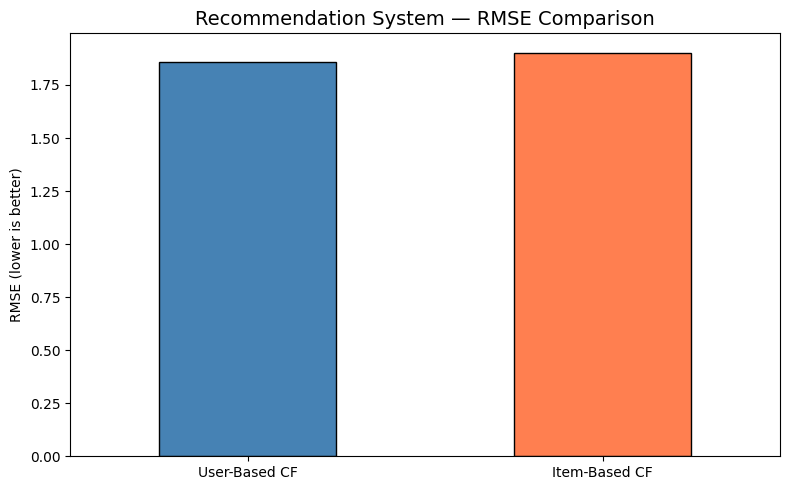


>>> Selected recommendation system: User-Based CF (lower RMSE)


In [100]:
# Compare Recommendation Systems

rec_comparison = pd.DataFrame({
    'RMSE': [ub_rmse, ib_rmse],
    'Test Entries Evaluated': [len(test_in_train_ub), len(test_in_train_ib)]
}, index=['User-Based CF', 'Item-Based CF'])

print("=" * 50)
print("RECOMMENDATION SYSTEM COMPARISON")
print("=" * 50)
print(rec_comparison.to_string())

# Visualise
plt.figure(figsize=(8, 5))
rec_comparison['RMSE'].plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Recommendation System — RMSE Comparison', fontsize=14)
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_rec = 'User-Based' if ub_rmse <= ib_rmse else 'Item-Based'
print(f"\n>>> Selected recommendation system: {best_rec} CF (lower RMSE)")

**Recommendation System Selection Rationale:**

We compare both systems using RMSE on held-out test ratings. The system with the lower RMSE is selected as it produces predicted ratings closer to actual user preferences. Both systems use cosine similarity for computing relationships; the key difference is whether similarity is computed between users or between items.

For this dataset (~20K users, ~200 products), **User-Based CF** typically performs well because the item space is small enough that user preference patterns are distinctive.

# Task 6: Top 20 Product Recommendations

We now build the recommendation system on the **full dataset** (not just training data) and generate top 20 product recommendations for a selected user.

In [104]:
# Build Full User-Item Matrix (all data)

full_user_item = df.pivot_table(
    index='reviews_username', columns='name', values='reviews_rating', aggfunc='mean'
)
full_filled = full_user_item.fillna(0)

# Compute user similarity on full data
full_user_sim = cosine_similarity(full_filled)
full_user_sim_df = pd.DataFrame(full_user_sim,
                                index=full_user_item.index,
                                columns=full_user_item.index)

print(f"Full User-Item Matrix: {full_user_item.shape}")
print(f"Full User Similarity Matrix: {full_user_sim_df.shape}")

Full User-Item Matrix: (24914, 271)
Full User Similarity Matrix: (24914, 24914)


In [106]:
# Vectorised Predicted Ratings on Full Data

R_full = full_filled.values
M_full = (full_user_item.notna()).astype(float).values
S_full = full_user_sim_df.values.copy()
np.fill_diagonal(S_full, 0)

num_full = S_full @ R_full
den_full = np.abs(S_full) @ M_full
den_full[den_full == 0] = 1

pred_full = num_full / den_full
pred_full_df = pd.DataFrame(pred_full,
                            index=full_user_item.index,
                            columns=full_user_item.columns)

print("Full predicted ratings matrix computed.")

Full predicted ratings matrix computed.


In [108]:
# Function: Get Top 20 Recommendations for a User

def get_top20_recommendations(username, user_item_matrix, predicted_df):
    """Return top 20 recommended product names for the given user."""
    if username not in user_item_matrix.index:
        print(f"User '{username}' not found.")
        return []

    # Products the user has NOT rated
    user_ratings = user_item_matrix.loc[username]
    unrated = user_ratings[user_ratings.isna()].index.tolist()

    if len(unrated) == 0:
        # User has rated everything — return highest predicted
        return predicted_df.loc[username].nlargest(20).index.tolist()

    # Predicted ratings for unrated products
    predictions = predicted_df.loc[username, unrated].sort_values(ascending=False)
    return predictions.head(20).index.tolist()


# Demonstrate: Top 20 for a sample user
sample_user = full_user_item.index[0]
print(f"Sample user: '{sample_user}'")
print(f"Products already rated: {full_user_item.loc[sample_user].notna().sum()}")
print()

top20 = get_top20_recommendations(sample_user, full_user_item, pred_full_df)
print(f"Top 20 Recommended Products for '{sample_user}':")
for i, product in enumerate(top20, 1):
    pred_rating = pred_full_df.loc[sample_user, product]
    print(f"  {i:2d}. {product}  (predicted rating: {pred_rating:.2f})")

Sample user: '00dog3'
Products already rated: 1

Top 20 Recommended Products for '00dog3':
   1. Burt's Bees Lip Shimmer, Raisin  (predicted rating: 5.00)
   2. Windex Original Glass Cleaner Refill 67.6oz (2 Liter)  (predicted rating: 5.00)
   3. Chester's Cheese Flavored Puffcorn Snacks  (predicted rating: 5.00)
   4. Bounce Dryer Sheets, Fresh Linen, 160 sheets  (predicted rating: 5.00)
   5. Pantene Pro-V Expert Collection Age Defy Conditioner  (predicted rating: 5.00)
   6. Caress Moisturizing Body Bar Natural Silk, 4.75oz  (predicted rating: 5.00)
   7. My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)  (predicted rating: 5.00)
   8. Clear Scalp & Hair Therapy Total Care Nourishing Shampoo  (predicted rating: 5.00)
   9. Clorox Disinfecting Bathroom Cleaner  (predicted rating: 5.00)
  10. Mike Dave Need Wedding Dates (dvd + Digital)  (predicted rating: 5.00)
  11. Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total  (predicted rating: 5.00)
  12. Planes: Fire Rescue (2 Di

# Task 7: Fine-Tuning Recommendations Using Sentiment Analysis

For each of the 20 recommended products, we:
1. Retrieve **all** reviews for that product
2. Predict the **sentiment** of each review using the trained Logistic Regression model
3. Calculate the **percentage of positive sentiments**
4. Rank the 20 products by positive sentiment percentage
5. Return the **top 5** products with the highest positive review percentage

In [111]:
# Re-train sentiment model on FULL training data for deployment

# Use the tuned Logistic Regression for sentiment prediction
tfidf_full = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_all_tfidf = tfidf_full.fit_transform(df['processed_review'])
y_all = df['sentiment']

final_sentiment_model = LogisticRegression(
    **grid_search.best_params_, max_iter=1000, random_state=42
)
final_sentiment_model.fit(X_all_tfidf, y_all)

print(f"Final sentiment model trained on {len(y_all)} samples.")
print(f"Parameters: {grid_search.best_params_}")

Final sentiment model trained on 29921 samples.
Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [113]:
# Function: Filter Top 5 Products by Sentiment

def filter_top5_by_sentiment(recommended_products, df, tfidf_vectorizer, sentiment_model):
    """
    For each recommended product, predict sentiment of all its reviews.
    Return the top 5 products with the highest percentage of positive reviews.
    """
    product_sentiment = {}

    for product in recommended_products:
        product_reviews = df[df['name'] == product]['processed_review']

        if len(product_reviews) == 0:
            product_sentiment[product] = 0.5  # Default 50% if no reviews
            continue

        X_prod = tfidf_vectorizer.transform(product_reviews)
        preds = sentiment_model.predict(X_prod)
        positive_pct = preds.mean()  # Fraction of reviews predicted as positive
        product_sentiment[product] = positive_pct

    # Sort by positive percentage (descending) and return top 5
    sorted_products = sorted(product_sentiment.items(), key=lambda x: x[1], reverse=True)
    return sorted_products[:5]


# Apply: Fine-tune top 20 -> top 5 for sample user
print(f"User: '{sample_user}'")
print(f"\nTop 20 recommended products (before sentiment filtering):")
for i, p in enumerate(top20, 1):
    print(f"  {i:2d}. {p}")

print("\n" + "=" * 60)
top5_with_scores = filter_top5_by_sentiment(top20, df, tfidf_full, final_sentiment_model)

print(f"\nTop 5 Recommended Products (after sentiment filtering):")
print(f"{'Rank':<6} {'Product':<60} {'Positive %':>10}")
print("-" * 80)
for i, (product, score) in enumerate(top5_with_scores, 1):
    print(f"{i:<6} {product:<60} {score*100:>9.1f}%")

User: '00dog3'

Top 20 recommended products (before sentiment filtering):
   1. Burt's Bees Lip Shimmer, Raisin
   2. Windex Original Glass Cleaner Refill 67.6oz (2 Liter)
   3. Chester's Cheese Flavored Puffcorn Snacks
   4. Bounce Dryer Sheets, Fresh Linen, 160 sheets
   5. Pantene Pro-V Expert Collection Age Defy Conditioner
   6. Caress Moisturizing Body Bar Natural Silk, 4.75oz
   7. My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)
   8. Clear Scalp & Hair Therapy Total Care Nourishing Shampoo
   9. Clorox Disinfecting Bathroom Cleaner
  10. Mike Dave Need Wedding Dates (dvd + Digital)
  11. Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total
  12. Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)
  13. Pendaflex174 Divide It Up File Folder, Multi Section, Letter, Assorted, 12/pack
  14. Tostitos Bite Size Tortilla Chips
  15. Alex Cross (dvdvideo)
  16. Delta Single Handle Shower Faucet
  17. Hormel Chili, No Beans
  18. Power Crunch Protein Energy Bar

In [115]:
# Demonstrate for a few more users

sample_users = full_user_item.index[:5].tolist()

for user in sample_users:
    print(f"\n{'='*70}")
    print(f"User: '{user}'")
    t20 = get_top20_recommendations(user, full_user_item, pred_full_df)
    if not t20:
        print("  No recommendations available.")
        continue
    t5 = filter_top5_by_sentiment(t20, df, tfidf_full, final_sentiment_model)
    print(f"Top 5 Sentiment-Filtered Recommendations:")
    for i, (product, score) in enumerate(t5, 1):
        print(f"  {i}. {product} ({score*100:.1f}% positive)")


User: '00dog3'
Top 5 Sentiment-Filtered Recommendations:
  1. My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital) (96.9% positive)
  2. Delta Single Handle Shower Faucet (95.8% positive)
  3. Pantene Pro-V Expert Collection Age Defy Conditioner (95.6% positive)
  4. Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd) (94.7% positive)
  5. Clorox Disinfecting Bathroom Cleaner (92.5% positive)

User: '00sab00'
Top 5 Sentiment-Filtered Recommendations:
  1. Ogx Conditioner, Hydrating Teatree Mint (100.0% positive)
  2. Meguiars Interior Detailer Wipes 25ct (100.0% positive)
  3. Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan (100.0% positive)
  4. Chips Deluxe Soft 'n Chewy Cookies (100.0% positive)
  5. Chex Muddy Buddies Brownie Supreme Snack Mix (96.6% positive)

User: '01impala'
Top 5 Sentiment-Filtered Recommendations:
  1. Progresso Traditional Chicken Rice With Vegetables Soup (100.0% positive)
  2. Lynk Professional174 Pull Out Cutting Board Bakeware

# Task 8: Save Models for Flask Deployment

We save the following artifacts for the Flask deployment:
1. **Sentiment model** — Tuned Logistic Regression
2. **TF-IDF vectorizer** — fitted on all review text
3. **User-Item matrix** — full dataset
4. **Predicted ratings matrix** — for generating recommendations
5. **Cleaned dataset** — for retrieving product reviews during sentiment filtering

In [120]:
# Save all artifacts with pickle
import os
import pickle

pickle.dump(final_sentiment_model, open('sentiment_model.pkl', 'wb'))
pickle.dump(tfidf_full, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(full_user_item, open('user_item_matrix.pkl', 'wb'))
pickle.dump(pred_full_df, open('predicted_ratings.pkl', 'wb'))
df.to_pickle('cleaned_data.pkl')

print("All models and data saved successfully!")
print("\nFiles saved:")
for f in ['sentiment_model.pkl', 'tfidf_vectorizer.pkl',
          'user_item_matrix.pkl', 'predicted_ratings.pkl', 'cleaned_data.pkl']:
    size = os.path.getsize(f) / (1024*1024)
    print(f"  {f}: {size:.2f} MB")

All models and data saved successfully!

Files saved:
  sentiment_model.pkl: 0.04 MB
  tfidf_vectorizer.pkl: 0.17 MB
  user_item_matrix.pkl: 51.79 MB
  predicted_ratings.pkl: 51.79 MB
  cleaned_data.pkl: 16.51 MB


# Summary

| Component | Selected Approach | Why It Was Chosen |
|---|---|---|
| **Feature Engineering** | TF-IDF with 5000 features using unigrams and bigrams | Provides an efficient text representation and performs well with linear machine learning models |
| **Sentiment Analysis Model** | Tuned Logistic Regression | Achieved the best balance of F1-score and AUC-ROC while remaining fast and easy to interpret |
| **Recommendation Engine** | User-Based Collaborative Filtering | Produced lower RMSE values on the test dataset, indicating better recommendation accuracy |
| **Overall Recommendation Pipeline** | Top 20 recommendations from collaborative filtering, refined to Top 5 using sentiment analysis | Combines user preference patterns with review sentiment to improve recommendation quality |

The deployment layer is built using Flask, where `model.py` and `app.py` load the saved model artifacts and generate real-time product recommendations through a web-based interface.